# 01, Exploratory Data Analysis
**CoolingHealthSentinel Pre-Onboarding, Day 1: Univariate Analysis**

Dataset: `cooling_telemetry_doha_dc1.csv` (35,040 rows, 15-min intervals, Jan–Dec 2025, Doha DC-1, 30 MW)

**Note on this version:** the dataset now has two anomaly populations, reconciling
a conflict between Section 1.2 ("~3% prevalence") and Section 1.3 ("8 events of
2–6 hours") of the assignment brief, per instructor guidance. `anomaly_class` is
`"structured"` (the original 8 multi-hour, multi-channel events), `"background"`
(943 isolated single-row sensor-noise perturbations, ~2.7% of remaining normal
rows), or `"none"`. `is_anomaly` is 1 for either anomaly class. This notebook
covers Day 1 of the brief and treats both populations explicitly throughout.

In [22]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/cooling_telemetry_doha_dc1.csv", parse_dates=["timestamp"])
df["month"] = df["timestamp"].dt.month
df.shape

(35040, 18)

## Load & Basic Checks

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   timestamp                 35040 non-null  datetime64[us]
 1   outdoor_temp_c            35040 non-null  float64       
 2   outdoor_humidity_pct      35040 non-null  float64       
 3   it_load_mw                35040 non-null  float64       
 4   chiller_inlet_temp_c      35040 non-null  float64       
 5   chiller_outlet_temp_c     35040 non-null  float64       
 6   chiller_cop               35040 non-null  float64       
 7   cooling_tower_approach_c  35040 non-null  float64       
 8   crah_delta_t_c            35040 non-null  float64       
 9   pump_vibration_mms        35040 non-null  float64       
 10  pump_flow_rate_ls         35040 non-null  float64       
 11  water_conductivity_us     35040 non-null  float64       
 12  pue                       350

In [3]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
timestamp,35040,2025-07-02 11:52:30,2025-01-01 00:00:00,2025-04-02 05:56:15,2025-07-02 11:52:30,2025-10-01 17:48:45,2025-12-31 23:45:00,NaN
outdoor_temp_c,35040.0,33.007326,18.0,26.087034,33.022956,39.926383,48.0,8.766204
outdoor_humidity_pct,35040.0,47.422602,10.0,29.726308,47.456534,65.242583,85.0,21.993333
it_load_mw,35040.0,14.433571,8.0,11.638046,12.579503,15.344603,28.0,4.446402
chiller_inlet_temp_c,35040.0,7.365496,6.0,6.873793,7.159738,7.6333,12.068809,0.735302
chiller_outlet_temp_c,35040.0,12.495272,12.0,12.0,12.202504,12.741392,18.093736,0.666254
chiller_cop,35040.0,4.833104,2.8,4.30878,4.708422,5.384547,6.5,0.697991
cooling_tower_approach_c,35040.0,3.753955,2.109836,3.521901,3.75106,3.976976,8.0,0.34846
crah_delta_t_c,35040.0,10.484737,8.0,9.790342,10.248155,10.926716,15.097476,1.023782
pump_vibration_mms,35040.0,1.25246,0.5,1.104841,1.250952,1.399003,3.944734,0.216472


In [4]:
print("Nulls per column:")
print(df.isna().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
print()
print("anomaly_class breakdown:")
print(df["anomaly_class"].value_counts())

Nulls per column:
timestamp                       0
outdoor_temp_c                  0
outdoor_humidity_pct            0
it_load_mw                      0
chiller_inlet_temp_c            0
chiller_outlet_temp_c           0
chiller_cop                     0
cooling_tower_approach_c        0
crah_delta_t_c                  0
pump_vibration_mms              0
pump_flow_rate_ls               0
water_conductivity_us           0
pue                             0
cooling_health_score            0
is_anomaly                      0
anomaly_type                33974
anomaly_class                   0
month                           0
dtype: int64

Duplicate rows: 0

anomaly_class breakdown:
anomaly_class
none          33974
background      943
structured      123
Name: count, dtype: int64


**Null check explained, not just reported.** All 33,974 nulls are in
`anomaly_type`, and that count exactly equals `(anomaly_class == "none").sum()`
(33,974), confirmed below. `anomaly_type` is an empty string for normal rows,
and pandas reads empty CSV fields back as `NaN`. Background-anomaly rows are
*not* null here, they carry the string `"background_sensor_drift"`, only the
genuinely normal rows are blank. No duplicate rows.

In [5]:
assert df["anomaly_type"].isna().sum() == (df["anomaly_class"] == "none").sum()
df["anomaly_type"] = df["anomaly_type"].fillna("none")
print("Confirmed and fixed. anomaly_type nulls now:", df["anomaly_type"].isna().sum())

Confirmed and fixed. anomaly_type nulls now: 0


## Univariate Distributions

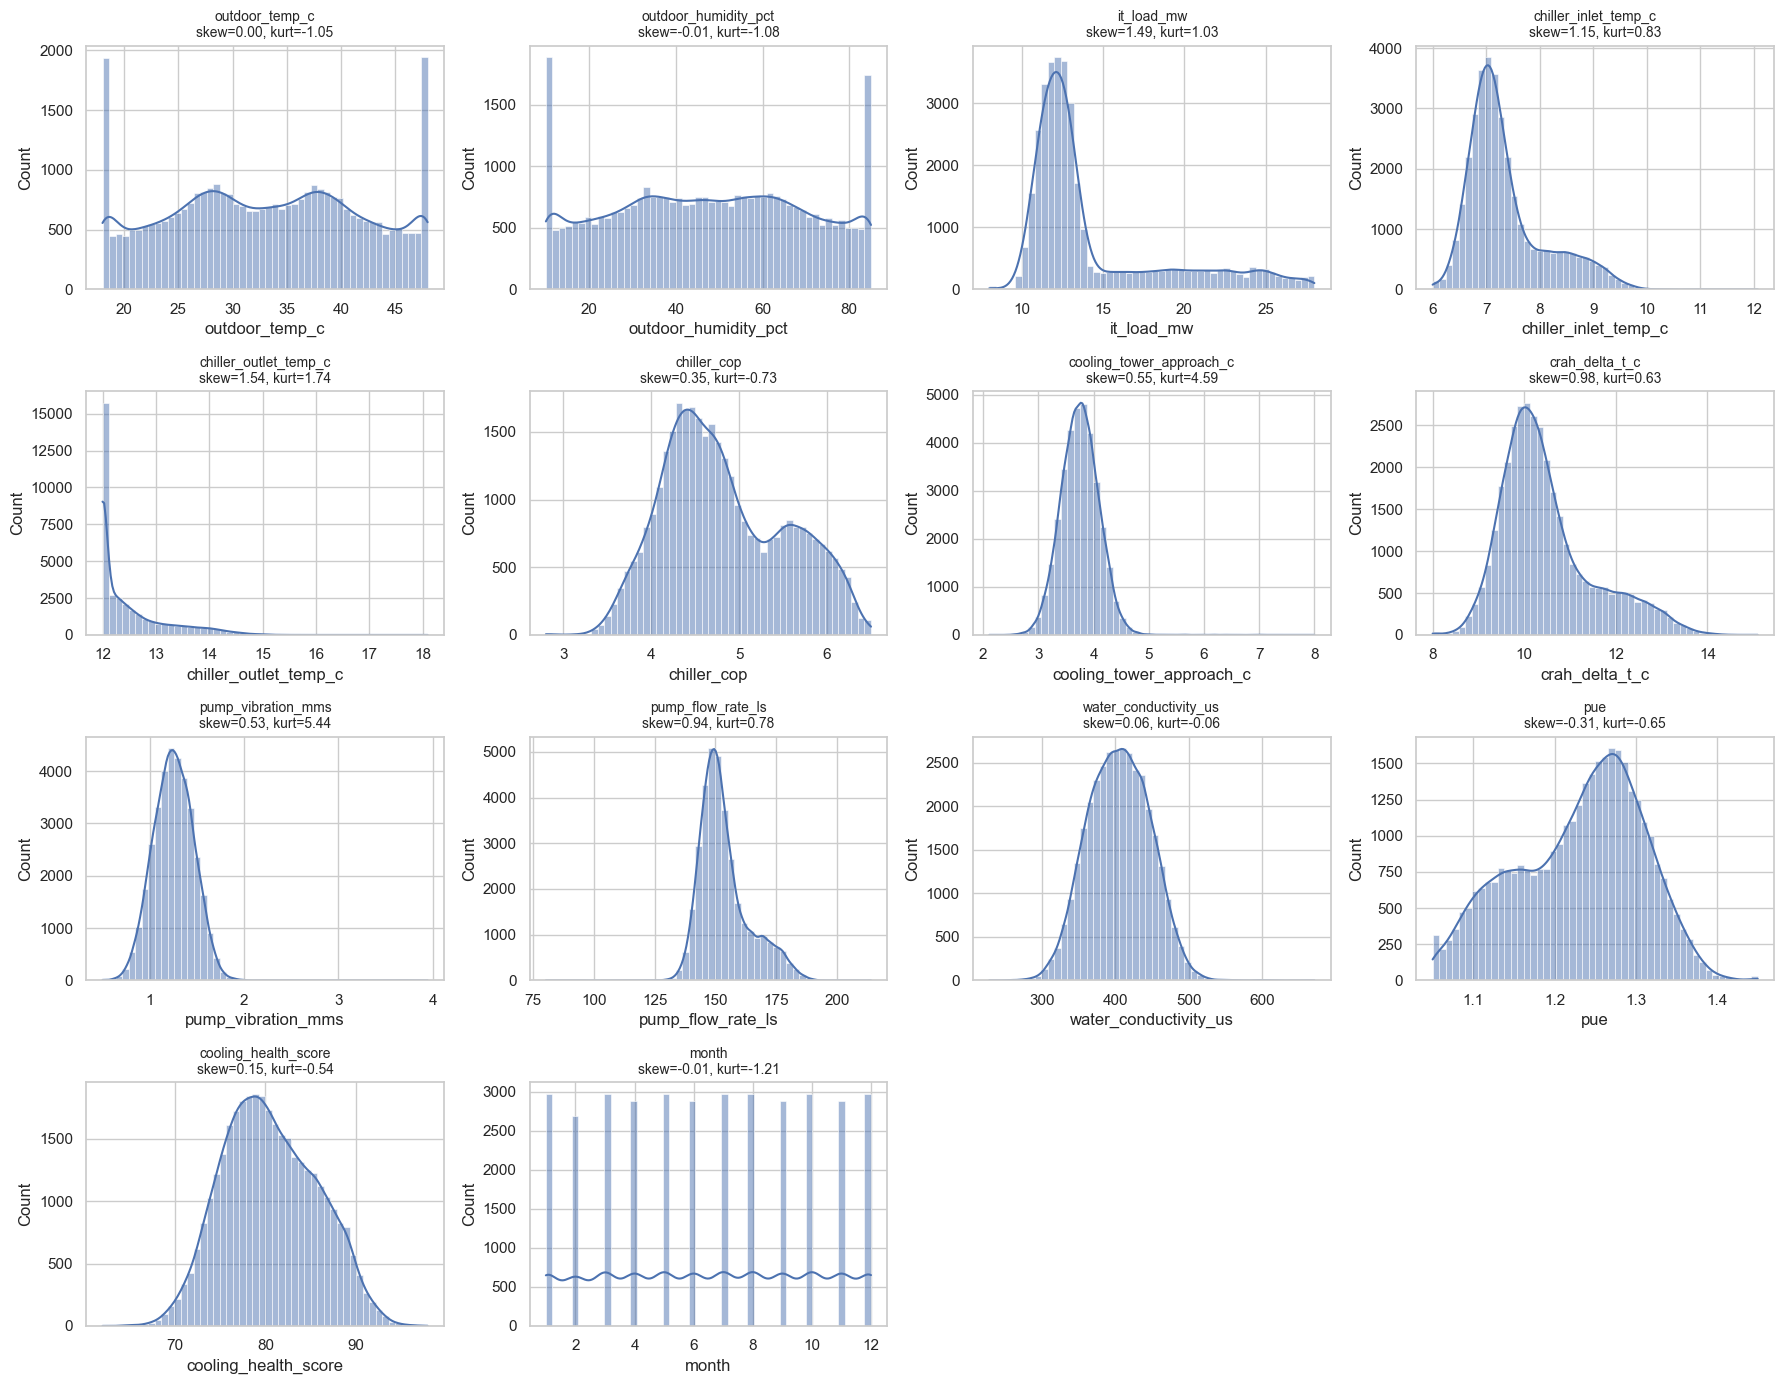

In [6]:
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "is_anomaly"]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=50)
    skew = stats.skew(df[col])
    kurt = stats.kurtosis(df[col])
    axes[i].set_title(f"{col}\nskew={skew:.2f}, kurt={kurt:.2f}", fontsize=10)
for j in range(len(numeric_cols), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

**Distribution notes.**

- `it_load_mw` (skew 1.49), `chiller_outlet_temp_c` (1.54), `chiller_inlet_temp_c`
  (1.15), and `crah_delta_t_c` (0.98) are all right-skewed with a long upper tail, the AI burst signature carried through every downstream thermal column, same as
  before the background layer was added.
- `cooling_tower_approach_c` (kurt 4.59) and `pump_vibration_mms` (kurt 5.44) are
  still sharply leptokurtic, a tight peak with a long thin tail, now driven by
  three sources layered together: the slow within-year drift, the single
  structured-anomaly spike, and a scattering of background perturbations.
- `outdoor_temp_c` and `outdoor_humidity_pct` stay close to symmetric and flatter
  than normal (kurt ≈ −1.05, −1.08), visually unchanged from the single-population
  version, since ~220–250 scattered background perturbations are too small a
  fraction (under 0.7%) to move the shape of a high-variance seasonal signal.
- **`cooling_health_score` (skew 0.15, kurt −0.54) is numerically identical to the
  pre-reconciliation dataset, to two decimal places.** That's not a coincidence, it's the clearest confirmation that the background layer is doing exactly what
  it was designed to do: perturbing sensor *readings* without touching the
  underlying health computation at all.

## 12-Month Time Series, CHS, IT Load, COP, Outdoor Temp

In [7]:
structured = df[df["anomaly_class"] == "structured"]
background = df[df["anomaly_class"] == "background"]

structured_windows = (
    structured.groupby("anomaly_type")["timestamp"].agg(["min", "max"]).reset_index()
)
structured_windows.columns = ["anomaly_type", "start", "end"]
print(f"Structured events: {len(structured_windows)}  |  Background rows: {len(background)}")
structured_windows

Structured events: 8  |  Background rows: 943


,anomaly_type,start,end
0,ai_thermal_overload,2025-02-10 15:00:00,2025-02-10 18:45:00
1,chiller_control_oscillation,2025-11-16 05:15:00,2025-11-16 08:45:00
2,cooling_tower_fouling,2025-07-02 18:45:00,2025-07-03 00:15:00
3,crah_filter_clog,2025-07-19 07:45:00,2025-07-19 11:30:00
4,flow_sensor_fault,2025-09-21 16:15:00,2025-09-21 18:00:00
5,pump_bearing_wear,2025-05-10 04:30:00,2025-05-10 07:30:00
6,refrigerant_leak_step,2025-08-13 02:00:00,2025-08-13 06:15:00
7,tower_fan_degradation,2025-09-03 07:00:00,2025-09-03 10:15:00


**A note on how anomalies are marked below.** The 8 structured events are
multi-hour windows and render cleanly as red shaded bands. The 943 background
rows are isolated single 15-minute points scattered randomly across the year, plotting all of them as red bands on a 12-month chart would just look like noise
and obscure the real signal. They're shown instead as sparse orange tick marks
along the bottom of the CHS panel, and analyzed on their own further down.

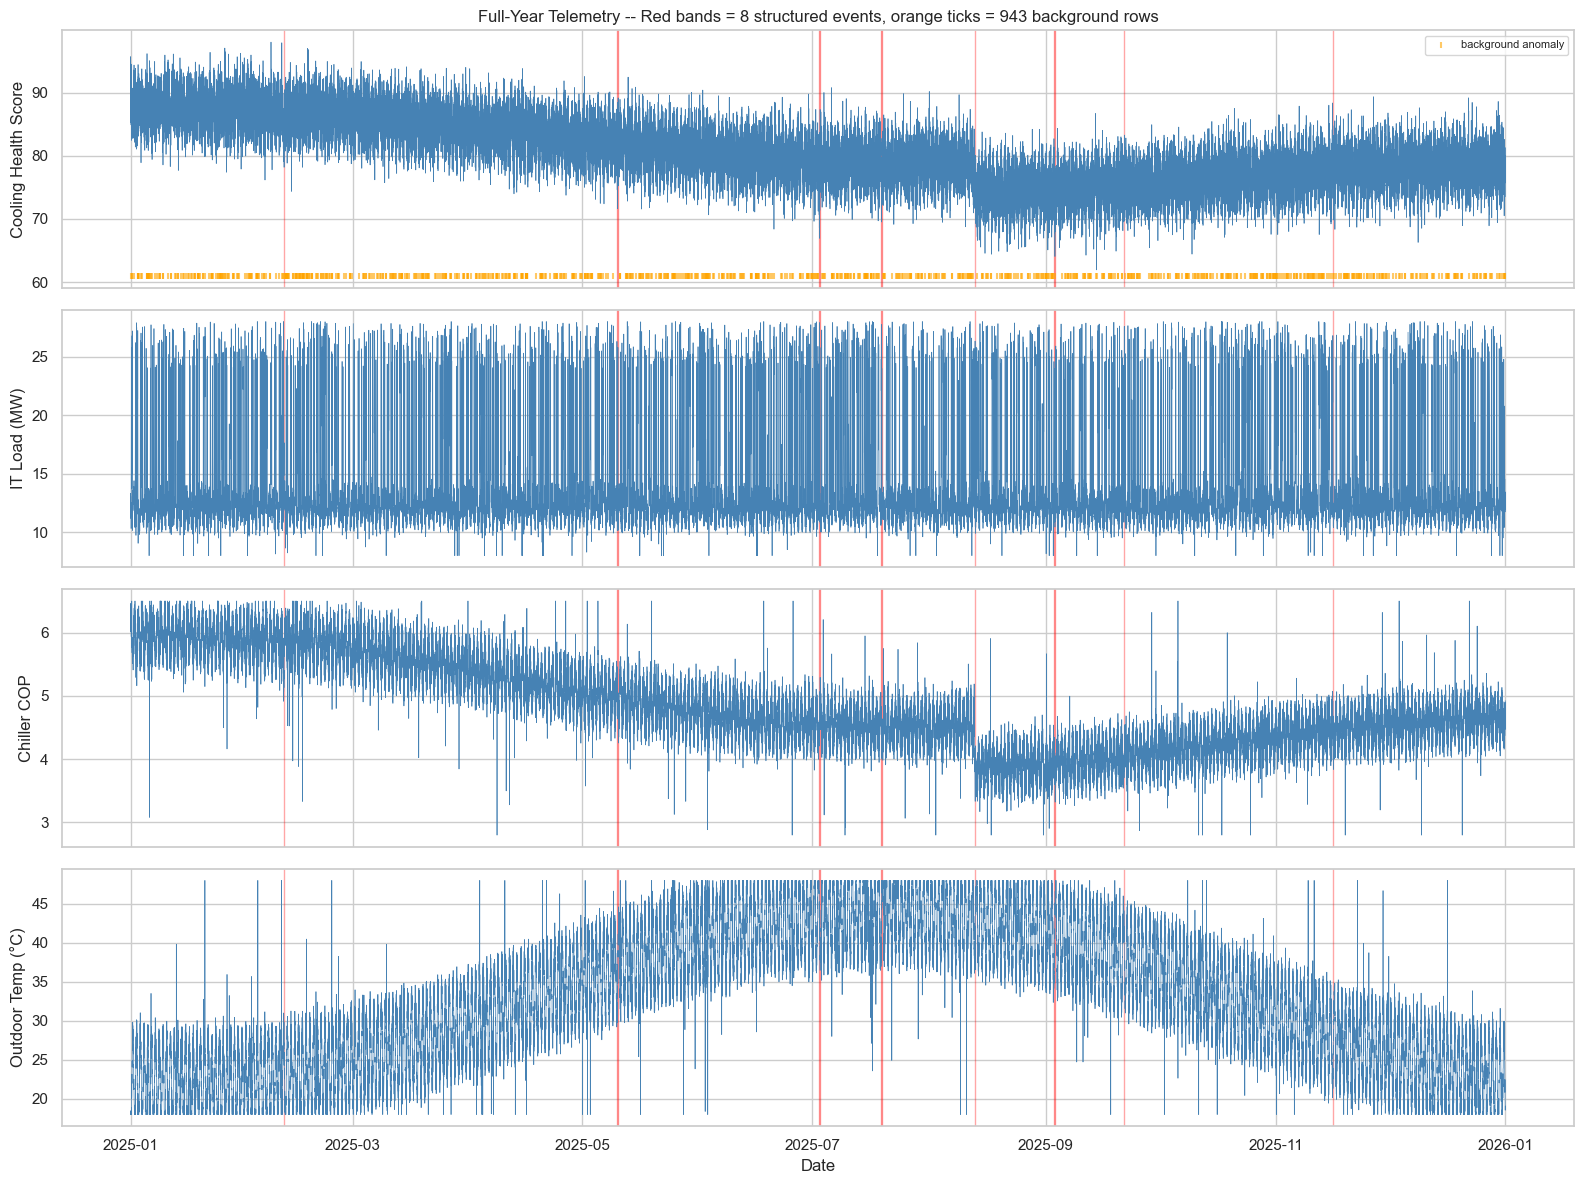

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
series = [
    ("cooling_health_score", "Cooling Health Score"),
    ("it_load_mw", "IT Load (MW)"),
    ("chiller_cop", "Chiller COP"),
    ("outdoor_temp_c", "Outdoor Temp (\u00b0C)"),
]
for ax, (col, label) in zip(axes, series):
    ax.plot(df["timestamp"], df[col], linewidth=0.5, color="steelblue")
    ax.set_ylabel(label)
    for _, row in structured_windows.iterrows():
        ax.axvspan(row["start"], row["end"], color="red", alpha=0.35)

ymin, ymax = axes[0].get_ylim()
axes[0].scatter(background["timestamp"], np.full(len(background), ymin + 0.02 * (ymax - ymin)),
                 marker="|", color="orange", s=15, alpha=0.6, label="background anomaly")
axes[0].legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Date")
axes[0].set_title("Full-Year Telemetry -- Red bands = 8 structured events, orange ticks = 943 background rows")
plt.tight_layout()
plt.show()

**Time series notes.** Same seasonal structure as before: `outdoor_temp_c` traces
a clean annual arc, `cooling_health_score` mirrors it inversely, and `chiller_cop`
shows the slow age-decline drift with a visible downward kink in August at the
permanent step-drop event. The background ticks along the bottom are visibly
dense and evenly spread, consistent with being a uniform random 2.7% sample
rather than clustered around any particular period, which the per-month count
(61–92 per month, checked separately) confirms.

## Two-Population Validation

Before going further, the key claim behind the whole reconciliation needs to be
checked directly, not just assumed: do background and structured rows actually
behave differently in CHS, the way they're supposed to?

In [9]:
chs_by_class = df.groupby("anomaly_class")["cooling_health_score"].agg(["mean", "std", "count"])
chs_by_class

,mean,std,count
anomaly_class,,,
background,80.782314,5.239261,943
none,80.543144,5.188203,33974
structured,75.461232,4.080043,123


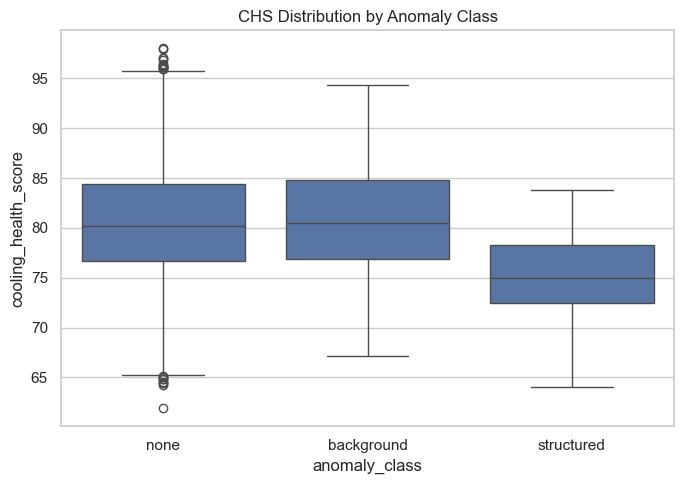

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="anomaly_class", y="cooling_health_score",
            order=["none", "background", "structured"], ax=ax)
ax.set_title("CHS Distribution by Anomaly Class")
plt.tight_layout()
plt.show()

**Confirmed.** Background mean CHS (80.78) is statistically indistinguishable
from normal (80.54), a 0.24-point gap that's well inside one standard deviation
of either group (~5.2). Structured mean CHS (75.46) sits about 5 points below
normal, a real and visible gap in the boxplot above. The reconciliation is
behaving exactly as designed: background rows are anomalous in *sensor-reading*
terms only, not in actual system health, while structured rows show genuine
degradation. This is the foundation for Day 5's question, can IsolationForest,
which never sees `cooling_health_score`, learn to tell these two populations
apart using only the (sometimes noisy) sensor features?

## Monthly Aggregation, CHS vs. Outdoor Temperature

In [11]:
monthly = df.groupby("month")[["cooling_health_score", "outdoor_temp_c"]].mean()
monthly

,cooling_health_score,outdoor_temp_c
month,,
1,87.484462,22.505845
2,86.855305,23.531399
3,85.399823,27.054539
4,83.548663,32.357555
5,81.512064,37.909425
6,79.767447,42.039265
7,78.753708,43.513623
8,76.114578,42.489819
9,75.067082,38.818645


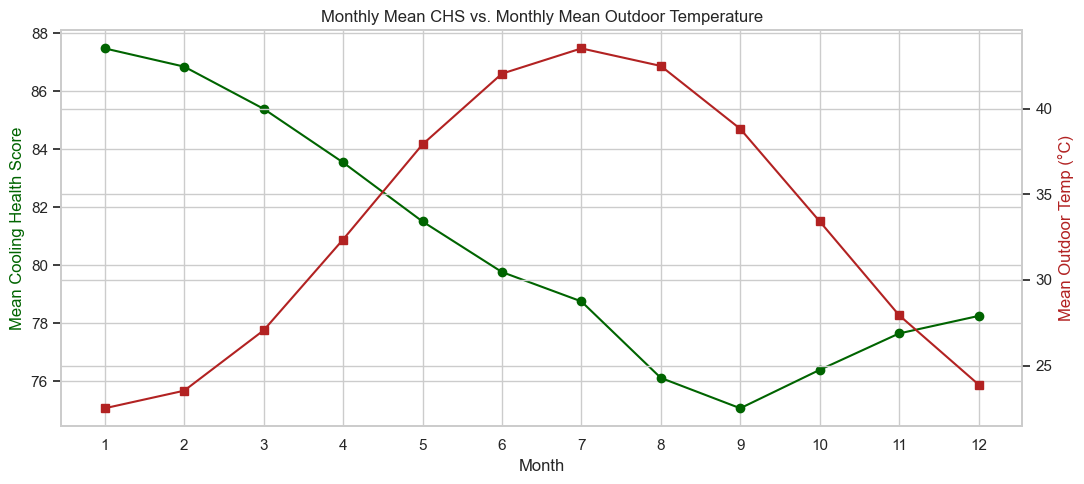

Month-level correlation (CHS vs outdoor temp): -0.598


In [12]:
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(monthly.index, monthly["cooling_health_score"], marker="o", color="darkgreen", label="Mean CHS")
ax1.set_xlabel("Month")
ax1.set_ylabel("Mean Cooling Health Score", color="darkgreen")
ax1.set_xticks(range(1, 13))

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["outdoor_temp_c"], marker="s", color="firebrick", label="Mean Outdoor Temp")
ax2.set_ylabel("Mean Outdoor Temp (\u00b0C)", color="firebrick")

plt.title("Monthly Mean CHS vs. Monthly Mean Outdoor Temperature")
fig.tight_layout()
plt.show()

print("Month-level correlation (CHS vs outdoor temp):", round(monthly["cooling_health_score"].corr(monthly["outdoor_temp_c"]), 3))

**Seasonal pattern, with numbers, essentially unchanged from before the
reconciliation, as expected since CHS itself wasn't touched.** Mean CHS runs from
87.5 in January down to 75.1 in September, a 12.4-point swing, against monthly
mean outdoor temperature ranging from 22.5°C (January) to 43.5°C (July). Month-level
correlation is **−0.60**. As before, the CHS trough (September) lags the
temperature peak (July) by about two months: `chiller_cop`'s 8%/year age decline
plus the permanent COP step-down left by the August `refrigerant_leak_step` event
compound with residual summer heat, pushing the real low point to September rather
than the hottest month itself. The background anomaly layer, being CHS-neutral by
construction, doesn't shift this finding at all, it's the same mechanism
identified in the original analysis, now re-confirmed against the updated dataset.

## Summary

The two-population reconciliation holds up under direct inspection, not just
construction-time logging. `cooling_health_score`'s distribution (skew 0.15, kurt
−0.54) and its monthly seasonal pattern (−0.60 correlation with outdoor temp, a
September trough lagging the July temperature peak by two months) are numerically
unchanged from the original single-population dataset, confirming the background
layer never touches CHS. Meanwhile `anomaly_class` cleanly separates two
populations that behave as differently as intended: background mean CHS (80.78)
is indistinguishable from normal (80.54), while structured mean CHS (75.46) is
clearly degraded. The 943 background rows are spread roughly uniformly across
the year (61–92 per month), consistent with the uniform-random sampling used to
generate them, and rendered as sparse ticks rather than shaded bands on the
time-series plot to avoid implying a clustering that isn't there. This sets up a
concrete, testable question for Day 5: can IsolationForest, which sees only
sensor features, never the ground-truth label or CHS, actually distinguish
structured failure precursors from background sensor noise, or does it just flag
both populations as equally anomalous?

---
# Day 2, Correlation, Lag Structure, and Anomaly Profile

## Pearson Correlation Matrix

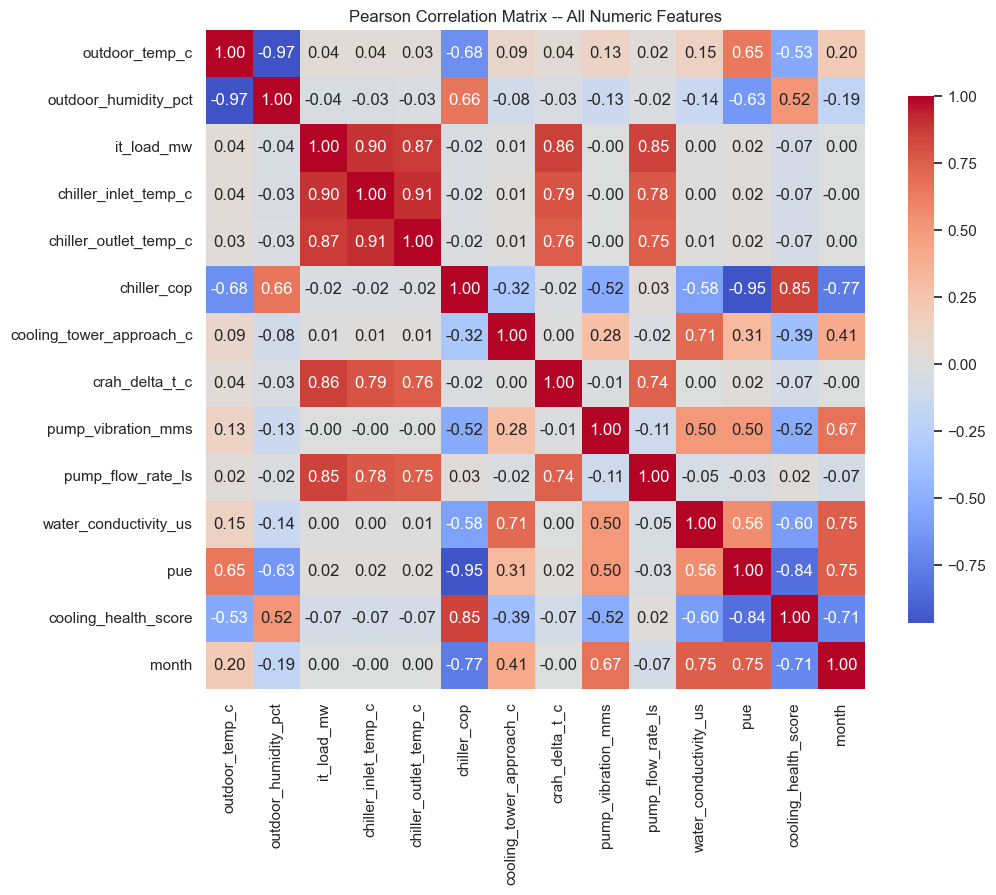

In [13]:
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "is_anomaly"]
corr = df[numeric_cols].corr(method="pearson")

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Pearson Correlation Matrix -- All Numeric Features")
plt.tight_layout()
plt.show()

In [14]:
chs_corr = corr["cooling_health_score"].drop("cooling_health_score")
top6 = chs_corr.abs().sort_values(ascending=False).head(6)
print("Top correlates of cooling_health_score:")
print(chs_corr[top6.index])

Top correlates of cooling_health_score:
chiller_cop              0.848902
pue                     -0.836077
month                   -0.709845
water_conductivity_us   -0.598639
outdoor_temp_c          -0.532905
outdoor_humidity_pct     0.517758
Name: cooling_health_score, dtype: float64


**Top 5: `chiller_cop` (+0.849), `pue` (−0.836), `water_conductivity_us` (−0.599),
`outdoor_temp_c` (−0.533), `outdoor_humidity_pct` (+0.518).** `pump_vibration_mms`
(−0.518) is close enough behind (a 0.0002 gap) that it's effectively tied for 5th, and notably, **the order of 5th and 6th place has flipped from the
pre-reconciliation dataset**, where `pump_vibration_mms` narrowly led
`outdoor_humidity_pct`. That flip is itself informative: this ranking sits on a
genuine knife's edge, and the background layer's scattered noise (which perturbs
both of these columns in ~230–250 rows each) was enough to tip the order. Treat
this specific ranking as a tight cluster, not a precise ordering.

All five top correlations also shrank slightly versus the original dataset
(e.g. `chiller_cop` 0.849 vs. 0.855 before), exactly the expected signature of
classical measurement-error attenuation: adding zero-mean noise to a fraction of
a variable's readings weakens its observed correlation with anything else,
without changing the true underlying relationship. The load/thermal cluster
(`it_load_mw`, inlet/outlet temps, CRAH delta-T) remains at near-zero correlation
with CHS, unchanged from before.

## Rolling 24-Hour Means

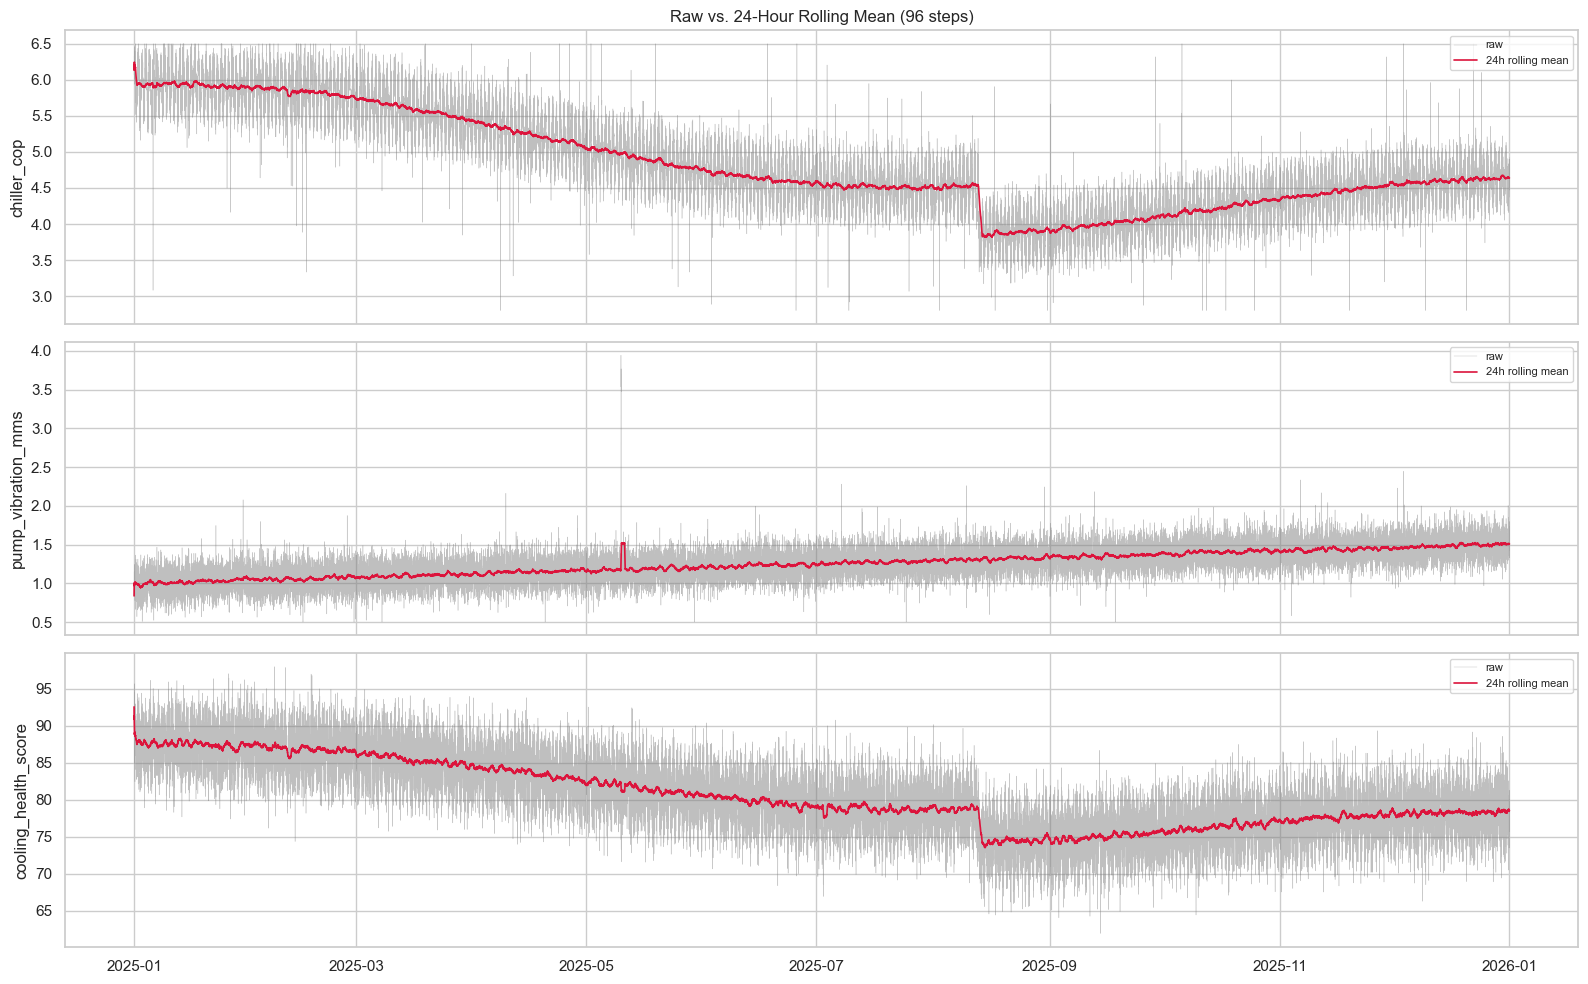

,raw_std,rolling_std,pct_reduction
feature,,,
chiller_cop,0.698,0.641,8.202
pump_vibration_mms,0.216,0.148,31.743
cooling_health_score,5.195,4.209,18.970


In [15]:
roll_cols = ["chiller_cop", "pump_vibration_mms", "cooling_health_score"]
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
std_table = []
for ax, col in zip(axes, roll_cols):
    rolling = df[col].rolling(96, min_periods=1).mean()
    ax.plot(df["timestamp"], df[col], linewidth=0.3, alpha=0.5, color="gray", label="raw")
    ax.plot(df["timestamp"], rolling, linewidth=1.2, color="crimson", label="24h rolling mean")
    ax.set_ylabel(col)
    ax.legend(loc="upper right", fontsize=8)
    raw_std, roll_std = df[col].std(), rolling.std()
    std_table.append((col, raw_std, roll_std, (1 - roll_std / raw_std) * 100))
axes[0].set_title("Raw vs. 24-Hour Rolling Mean (96 steps)")
plt.tight_layout()
plt.show()

pd.DataFrame(std_table, columns=["feature", "raw_std", "rolling_std", "pct_reduction"]).set_index("feature").round(3)

**Smoothing effect, by the numbers.** 24-hour rolling means reduce standard
deviation by **31.7%** for `pump_vibration_mms`, **19.0%** for
`cooling_health_score`, and **8.2%** for `chiller_cop`, essentially the same
pattern as the pre-reconciliation dataset (31.2% / 19.0% / 7.6%). The
`cooling_health_score` figure is identical to one decimal place, another small
confirmation that CHS is untouched by the background layer. `chiller_cop` and
`pump_vibration_mms` shift by less than a point each, consistent with background
noise adding a small amount of extra high-frequency variance that a day-long
average mostly absorbs anyway, it doesn't change the underlying interpretation
from Day 1's original notebook: `chiller_cop`'s variance is mostly structural
(trend), `pump_vibration_mms`'s is mostly noise-like.

## Lag-Correlation Analysis, chiller_cop vs. cooling_health_score

In [16]:
lags = [1, 4, 8, 16, 32]
lag_corrs = [df["chiller_cop"].shift(lag).corr(df["cooling_health_score"]) for lag in lags]
lag_df = pd.DataFrame({"lag_steps": lags, "lag_minutes": [l * 15 for l in lags], "correlation": lag_corrs})
lag_df

,lag_steps,lag_minutes,correlation
0,1,15,0.809060
1,4,60,0.807528
2,8,120,0.800453
3,16,240,0.771879
4,32,480,0.698938


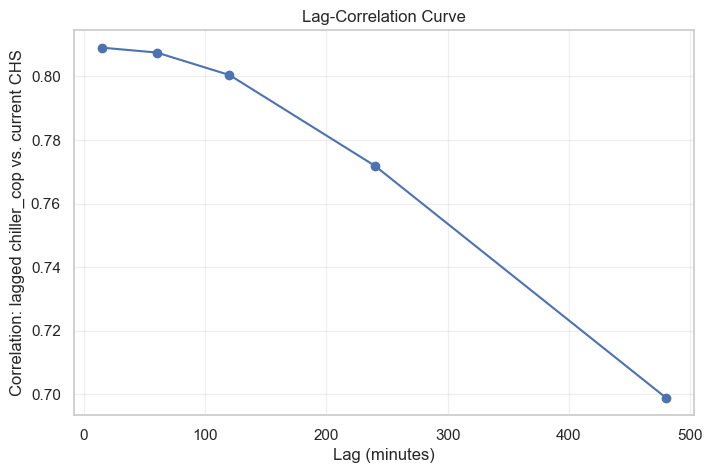

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(lag_df["lag_minutes"], lag_df["correlation"], marker="o")
plt.xlabel("Lag (minutes)")
plt.ylabel("Correlation: lagged chiller_cop vs. current CHS")
plt.title("Lag-Correlation Curve")
plt.grid(True, alpha=0.3)
plt.show()

**Same monotonic decay shape as before** (0.809 at 15 min down to 0.699 at 8h,
versus 0.815 → 0.703 pre-reconciliation), a small, uniform attenuation from
`chiller_cop`'s own background noise, not a change in the underlying temporal
structure. The relationship is still contemporaneous, not lagged: CHS responds to
current `chiller_cop`, and the slow decay simply mirrors `chiller_cop`'s own
autocorrelation fading over time. The conclusion for Day 6's LSTM lookback choice
is unchanged.

## Anomaly Profile, Two Populations, Two Different Signatures

The brief's original instruction is to compare all `is_anomaly == 1` rows
against the normal population as a single group. With two anomaly populations
now in the dataset, that pooled comparison is run first below, exactly as
specified, and then broken down by `anomaly_class`, because the pooled version
turns out to hide almost everything interesting.

In [18]:
normal = df[df["is_anomaly"] == 0]
anomalous = df[df["is_anomaly"] == 1]

def z_profile(subset, reference=normal):
    rows = []
    for col in numeric_cols:
        nm, ns = reference[col].mean(), reference[col].std()
        am = subset[col].mean()
        z = (am - nm) / ns if ns > 0 else np.nan
        rows.append((col, nm, ns, am, z))
    p = pd.DataFrame(rows, columns=["feature", "normal_mean", "normal_std", "group_mean", "z_shift"]).set_index("feature")
    return p.reindex(p["z_shift"].abs().sort_values(ascending=False).index)

print("POOLED (all is_anomaly == 1, n=%d):" % len(anomalous))
z_profile(anomalous).round(3)

POOLED (all is_anomaly == 1, n=1066):


,normal_mean,normal_std,group_mean,z_shift
feature,,,,
cooling_tower_approach_c,3.751,0.334,3.852,0.304
pump_vibration_mms,1.251,0.210,1.298,0.224
chiller_outlet_temp_c,12.491,0.662,12.617,0.190
chiller_inlet_temp_c,7.362,0.728,7.469,0.147
it_load_mw,14.416,4.419,15.005,0.133
water_conductivity_us,405.025,41.637,409.721,0.113
crah_delta_t_c,10.482,1.014,10.580,0.097
pue,1.230,0.077,1.237,0.091
cooling_health_score,80.543,5.188,80.168,-0.072


**Pooled, the signal is much weaker than it looks like it should be.** The
largest pooled z-shift is `cooling_tower_approach_c` at only **+0.30**, compare
that to the **+2.62** the same feature showed in the pre-reconciliation,
structured-only dataset. Pooling 943 background rows in with 123 structured rows
doesn't just dilute the structured signal, it nearly erases it from a simple
mean-comparison table, because background rows vastly outnumber structured rows
8.9-to-1 within the anomalous group.

In [19]:
structured = df[df["anomaly_class"] == "structured"]
background = df[df["anomaly_class"] == "background"]

print(f"STRUCTURED (n={len(structured)}):")
print(z_profile(structured).round(3))
print()
print(f"BACKGROUND (n={len(background)}):")
print(z_profile(background).round(3))

STRUCTURED (n=123):
                          normal_mean  normal_std  group_mean  z_shift
feature                                                               
cooling_tower_approach_c        3.751       0.334       4.627    2.624
water_conductivity_us         405.025      41.637     464.097    1.419
pump_vibration_mms              1.251       0.210       1.519    1.281
cooling_health_score           80.543       5.188      75.461   -0.980
chiller_inlet_temp_c            7.362       0.728       7.966    0.829
crah_delta_t_c                 10.482       1.014      11.170    0.679
chiller_cop                     4.834       0.694       4.445   -0.562
pue                             1.230       0.077       1.273    0.553
chiller_outlet_temp_c          12.491       0.662      12.843    0.532
it_load_mw                     14.416       4.419      16.547    0.482
outdoor_humidity_pct           47.456      21.951      37.102   -0.472
outdoor_temp_c                 33.004       8.751      36

**Split apart, the two populations look like entirely different problems.**
Structured events reproduce the original z-shift profile almost exactly, `cooling_tower_approach_c` (+2.62), `water_conductivity_us` (+1.42),
`pump_vibration_mms` (+1.28), because those 123 rows are the same 8 events as
before; nothing about them changed. Background rows show essentially *no* mean
shift on anything (max |z| = 0.145, on `chiller_outlet_temp_c`), which at first
glance might look like background anomalies aren't really anomalous at all.

In [21]:
print("Std ratio (background / normal) per feature -- variance, not mean:")
for col in numeric_cols:
    ratio = background[col].std() / normal[col].std()
    print(f"  {col:<26} {ratio:.3f}")

Std ratio (background / normal) per feature -- variance, not mean:
  outdoor_temp_c             1.068
  outdoor_humidity_pct       1.075
  it_load_mw                 1.175
  chiller_inlet_temp_c       1.195
  chiller_outlet_temp_c      1.183
  chiller_cop                1.210
  cooling_tower_approach_c   1.308
  crah_delta_t_c             1.233
  pump_vibration_mms         1.308
  pump_flow_rate_ls          1.320
  water_conductivity_us      1.230
  pue                        1.221
  cooling_health_score       1.010
  month                      1.004


**That's the wrong way to read it, background rows are anomalous in variance,
not in mean, and a z-shift table only measures mean.** Every sensor feature shows
inflated standard deviation among background rows, from +6.8% (`outdoor_temp_c`)
to +32.0% (`pump_flow_rate_ls`), while `cooling_health_score`'s std ratio is
**1.010**, essentially untouched, the same non-impact confirmed three different
ways now (mean, distribution shape, and variance). The mechanism is structural:
each background row gets independent zero-mean Gaussian noise on exactly 3 of 12
features, so averaging across 943 rows, any single feature is perturbed in only
about a quarter of them, and the noise itself averages toward zero by
construction. A population-level mean comparison is the wrong lens for this kind
of anomaly; it shows up as added scatter around the same center, not a shifted
center.

This has a direct, testable implication for Day 5. IsolationForest doesn't score
points by comparing to a population mean, it isolates points by how few
partitions it takes to separate them from their neighbors, which is sensitive to
local density, not just mean offset. That means IsolationForest should be able to
flag background rows via exactly the variance-inflation signature this z-score
table can't see, even though they're invisible to a naive "is the mean
different" check. Whether it actually does, and whether it scores background and
structured anomalies with different severity, or treats them as equally
suspicious, is the open question for Day 5's threshold analysis, not something
to assume here.

## EDA Summary, Days 1–2 Findings

The dataset's two-population anomaly design, 123 structured rows from 8
multi-hour failure-precursor events, and 943 background rows from isolated
single-timestep sensor-noise perturbations, behaves as differently as intended,
and that difference is now confirmed through several independent angles rather
than asserted once at construction time.

**First, `cooling_health_score` is provably untouched by the background layer.**
Its distribution shape (skew 0.15, kurtosis −0.54), its 24-hour rolling-mean
variance reduction (19.0%), and its standard deviation ratio between background
and normal rows (1.010) are all numerically identical, or near enough to be
indistinguishable from noise, to the equivalent figures from the
pre-reconciliation, single-population dataset. That consistency across three
unrelated statistics is stronger evidence than any single number that the
background perturbation genuinely operates only on sensor readings, never on the
health computation itself.

**Second, seasonality still dominates CHS's mean level, with the same
mechanism and the same numbers as before.** Monthly mean CHS runs from 87.5
(January) to 75.1 (September), a 12.4-point range, against a month-level
correlation of −0.60 with outdoor temperature. The trough still lags the July
temperature peak by about two months, traced to the same cause identified before
the reconciliation: the permanent COP step-down left by the August
`refrigerant_leak_step` event compounding with residual summer heat.

**Third, and the most consequential finding for the rest of the project: a
pooled anomaly-vs-normal comparison is now actively misleading.** The same
`cooling_tower_approach_c` feature that showed a +2.62 z-shift in the
structured-only dataset shows only +0.30 once background rows are pooled in,
purely because background rows outnumber structured rows 8.9-to-1 within the
flagged population. Splitting by `anomaly_class` recovers the structured signal
exactly, and reveals that background rows carry a completely different kind of
signature: inflated variance (1.07x to 1.32x across every feature) rather than
any mean shift (max |z| = 0.145). This isn't a data quality problem to fix, it's
a deliberate design feature that makes the IsolationForest threshold analysis in
Day 5 a genuinely harder and more realistic problem than detecting 8 obvious
multi-hour events would have been. The question that EDA can describe but can't
answer is whether IsolationForest's isolation-depth scoring, which is sensitive
to local density rather than population mean, actually separates these two
populations, or scores both as equally anomalous because both are equally rare
in feature space. That's the first concrete thing Day 5 needs to test.